<a href="https://colab.research.google.com/github/felipe24I/AprendizajeMaquina/blob/main/Reducci%C3%B3n_de_Dimensi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Reducción de Dimensiones en Machine Learning

La **reducción de dimensiones** en *Machine Learning* es una técnica que busca **disminuir el número de variables (o características)** que describen los datos, **manteniendo la información más importante posible**. Es especialmente útil cuando se trabaja con datos de alta dimensión, como imágenes, texto o señales.

---

##  ¿Por qué reducir dimensiones?

-  Mejora el rendimiento de los algoritmos (menos cálculo).
-  Reduce el riesgo de *overfitting* (menos ruido, más generalización).
-  Facilita la visualización de datos (por ejemplo, llevar a 2D o 3D).
-  Disminuye el almacenamiento y los tiempos de entrenamiento.

---

##  Tipos de técnicas de reducción de dimensiones

### 1. Técnicas lineales

- **PCA (Análisis de Componentes Principales)**  
  Proyecta los datos en un nuevo espacio con menos ejes, eligiendo los que explican más varianza.

- **LDA (Análisis Discriminante Lineal)**  
  Similar a PCA, pero además tiene en cuenta las etiquetas para separar mejor las clases.

### 2. Técnicas no lineales

- **t-SNE (t-distributed Stochastic Neighbor Embedding)**  
  Ideal para visualizar en 2D datos complejos con estructuras no lineales.

- **UMAP (Uniform Manifold Approximation and Projection)**  
  Alternativa moderna a t-SNE, más rápida y conserva mejor la estructura global.

---

##  Ejemplo práctico

Supón que tienes una base de datos con **500 características por muestra** (como imágenes). No todas las características son útiles o informativas.  
Usando **PCA**, puedes reducirlas a, por ejemplo, **50 componentes** que **conservan el 95% de la información original**.

---

##  Nota clave

Reducir dimensiones **no siempre es necesario**, pero es una herramienta poderosa para:

- Preprocesamiento de datos  
- Visualización exploratoria  
- Reducción de ruido

# **Ejercicio 1**

- Presente el problema de optimización de PCA como un algoritmo generativo (reconstrucción o filtrado de datos), y compare el problema de optimización desde el punto de vista generativo vs. preservación de la varianza.

# **Solución:**

#  PCA como Problema de Optimización

El Análisis de Componentes Principales (PCA) se puede entender desde dos enfoques distintos, aunque equivalentes en su solución matemática: **preservación de varianza** y **modelo generativo por reconstrucción**.

---

##  Enfoque 1: Preservación de la Varianza (Formulación Clásica)

El objetivo es encontrar un conjunto de direcciones ortogonales (componentes) que **maximicen la varianza** de los datos proyectados.

### Problema de optimización:

$$
\max_{\mathbf{w}} \quad \mathrm{Var}(\mathbf{w}^\top \mathbf{x}) \quad \text{sujeto a} \quad \|\mathbf{w}\| = 1
$$

- $x$ es un vector de datos centrado (media 0).
- $w$ es una dirección de proyección (componente principal).
- La solución corresponde a los **autovectores** de la matriz de covarianza $\Sigma = \mathbb{E}[xx^\top]$, asociados con los mayores autovalores.

---

##  Enfoque 2: Reconstrucción Mínima (Modelo Generativo)

Este enfoque interpreta PCA como un **modelo generativo lineal** que busca **reconstruir los datos originales** a partir de una representación comprimida.

### Problema de optimización:

$$
\min_{\mathbf{W}, \mathbf{Z}} \quad \| X - ZW^\top \|_F^2 \quad \text{sujeto a} \quad W^\top W = I
$$

- $X \in \mathbb{R}^{n \times d}$: matriz de datos centrados.
- $W \in \mathbb{R}^{d \times k}$: base ortonormal de proyección (k componentes).
- $Z = XW$: representación en espacio reducido (latente).
- Se busca minimizar el **error de reconstrucción** en norma de Frobenius.

---

##  Comparación de Enfoques

| Aspecto                   | Preservación de Varianza           | Reconstrucción (Modelo Generativo)     |
|--------------------------|------------------------------------|----------------------------------------|
| **Objetivo**             | Maximizar varianza proyectada      | Minimizar error de reconstrucción      |
| **Motivación**           | Retener la mayor información       | Obtener una representación comprimida  |
| **Tipo de Optimización** | Maximización                       | Minimización                           |
| **Resultado Matemático** | Autovectores de la covarianza      | Misma solución: vectores principales   |
| **Aplicación común**     | Visualización, reducción de ruido  | Codificación, compresión de datos      |

---

##  Intuición

Ambos enfoques llevan al mismo resultado:

> **La mejor subestructura lineal que explica los datos (por varianza o reconstrucción) está dada por los autovectores principales de la matriz de covarianza.**


#**Ejercicio 2**

- Presente un paralelo entre el problema de optimización de PCA y el de Kernel PCA.

#**Solución**

# Paralelo entre PCA y Kernel PCA

Tanto **PCA** como **Kernel PCA** son técnicas de reducción de dimensiones, pero mientras PCA es lineal, **Kernel PCA** permite encontrar **estructuras no lineales** en los datos utilizando el "truco del kernel".

---

##  Objetivo general

| Técnica      | Objetivo                                                                 |
|--------------|--------------------------------------------------------------------------|
| **PCA**      | Encontrar una proyección lineal que maximice la varianza                 |
| **Kernel PCA** | Encontrar una proyección no lineal (en un espacio de mayor dimensión) que maximice la varianza |

---

##  Formulación del problema

###  PCA (clásico)

Busca resolver:

$$
\max_{\mathbf{w}} \quad \mathrm{Var}(\mathbf{w}^\top \mathbf{x}) \quad \text{sujeto a} \quad \|\mathbf{w}\| = 1
$$

Equivalente a encontrar los autovectores de la matriz de covarianza:

$$
\Sigma = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})(x_i - \bar{x})^\top
$$

---

###  Kernel PCA

Primero, se mapea cada dato $x_i$ a un espacio de mayor dimensión mediante una función no lineal $\phi(x_i)$.  
Luego, se realiza PCA en ese espacio sin calcular $\phi$ directamente, usando el **truco del kernel**.

Problema de optimización:

$$
\max_{\mathbf{\alpha}} \quad \mathbf{\alpha}^\top K \mathbf{\alpha} \quad \text{sujeto a} \quad \|\mathbf{\alpha}\| = 1
$$

- $K$ es la **matriz de kernel** definida como $K_{ij} = k(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle$
- Se resuelve un problema de autovalores sobre $K$

---

##  Comparación conceptual

| Aspecto                   | PCA                                      | Kernel PCA                                                |
|--------------------------|-------------------------------------------|-----------------------------------------------------------|
| **Tipo de proyección**   | Lineal                                    | No lineal (implícita a través del kernel)                |
| **Espacio de trabajo**   | Espacio original $\mathbb{R}^d$           | Espacio transformado $\mathcal{H}$ mediante $\phi(x)$    |
| **Matriz usada**         | Matriz de covarianza                      | Matriz de kernel $K$                                     |
| **Descomposición**       | Autovalores de $\Sigma$                   | Autovalores de $K$                                       |
| **Capacidad expresiva**  | Limitada a estructuras lineales           | Captura relaciones no lineales                           |
| **Visualización**        | Direcciones de máxima varianza lineales   | Proyecciones no lineales (más complejas de interpretar)  |

---

##  Intuición

- **PCA** busca las direcciones más informativas *en el espacio original*.
- **Kernel PCA** transforma los datos a un espacio más rico (potencialmente infinito) donde las **estructuras lineales en ese nuevo espacio corresponden a relaciones no lineales en el original**.

> Ambos métodos buscan maximizar la varianza, pero Kernel PCA lo hace en un espacio transformado usando funciones kernel (por ejemplo: RBF, polinomial).

---

##  Ejemplo de kernel común

- **Kernel Gaussiano (RBF):**
  $$
  k(x, x') = \exp\left(-\frac{\|x - x'\|^2}{2\sigma^2}\right)
  $$

- **Kernel Polinomial:**
  $$
  k(x, x') = (\langle x, x' \rangle + c)^d
  $$

---

#**Ejercicio 3**

##**Parte 1**

Consulte en que consiste el algoritmo [eigenfaces](https://direct.mit.edu/jocn/article/3/1/71/3025/Eigenfaces-for-Recognition). Compare el modelo de eigenfaces para reducción de dimensión con el algoritmo PCA. Aplique eigenfaces a Mnist sobre el conjunto `X_train` y grafique las dos primeras dimensiones con las imagenes originales sobre cada punto proyectado, y presente las cinco primeras "eigenfaces" en dibujo tipo imagen.

#**Solución**

# Eigenfaces para Reconocimiento Facial

El algoritmo **Eigenfaces** fue propuesto por Turk y Pentland (1991) y se basa en aplicar **PCA al espacio de imágenes faciales** para lograr tanto **reducción de dimensión** como **reconocimiento de rostros**.

El concepto principal es representar una imagen de rostro como una **combinación lineal de "rostros base" (eigenfaces)** obtenidos a través de PCA.

---

## ¿En qué consiste el algoritmo de Eigenfaces?

1. **Representación de imágenes**:  
   Cada imagen facial se convierte en un **vector** unidimensional concatenando todas sus filas/píxeles.

2. **Promediado y centrado**:  
   Se calcula la **imagen promedio** $\bar{x}$ y se centran todas las imágenes restando este promedio.

3. **Aplicación de PCA**:  
   Se calcula la **matriz de covarianza** y se obtienen los **autovectores (eigenfaces)** correspondientes a las direcciones de máxima varianza.

4. **Reducción de dimensión**:  
   Cada imagen se proyecta sobre los primeros $k$ autovectores para obtener una representación comprimida (en el "espacio de rostros").

5. **Reconocimiento o reconstrucción**:  
   Se usa la distancia entre estas proyecciones comprimidas para tareas como clasificación, verificación o reconstrucción.

---

## Eigenfaces = PCA aplicado a imágenes

En esencia, **Eigenfaces no es un algoritmo distinto de PCA**, sino una **aplicación directa de PCA al problema de reconocimiento facial**.

- Los **"eigenfaces"** son los **autovectores** de la matriz de covarianza de las imágenes centradas.
- Estos autovectores representan **las direcciones de mayor variación facial** en el conjunto de entrenamiento.
- El nombre "eigenfaces" proviene del hecho de que los autovectores pueden visualizarse como imágenes borrosas que representan patrones faciales fundamentales.

---

## Comparación: PCA vs Eigenfaces

| Aspecto                       | PCA (General)                             | Eigenfaces (PCA aplicado a rostros)        |
|------------------------------|--------------------------------------------|---------------------------------------------|
| **Dominio de aplicación**    | Cualquier tipo de datos                    | Imágenes faciales                           |
| **Entrada**                  | Vectores de características                | Imágenes convertidas en vectores            |
| **Objetivo**                 | Reducción de dimensión / compresión        | Reconocimiento facial / compresión          |
| **Autovectores**             | Direcciones principales del conjunto de datos | "Rostros base" (eigenfaces)              |
| **Interpretación visual**    | Difícil de interpretar                     | Se pueden visualizar como caras             |
| **Nombre del método**        | PCA                                       | PCA con nombre específico: Eigenfaces       |
| **Aplicaciones comunes**     | Compresión, preprocesamiento               | Verificación y reconocimiento facial        |

---

##  Nota clave

> El modelo de **Eigenfaces es PCA especializado en imágenes faciales**, y su utilidad radica en que la reducción de dimensión no solo ahorra almacenamiento y computación, sino que **captura los patrones más importantes para distinguir entre personas**.

---

##  Referencia original

Turk, M., & Pentland, A. (1991). [Eigenfaces for recognition](https://direct.mit.edu/jocn/article/3/1/71/3025/Eigenfaces-for-Recognition). *Journal of Cognitive Neuroscience, 3*(1), 71–86.



#**Programación**

#**base de datos Mnist que tiene 784 dimensiones de entrada**

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

mnist = keras.datasets.mnist #cargar fashion mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X = X_train.reshape(X_train.shape[0], -1)/255.
y = y_train

print(X.shape,y.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 784) (60000,)


#**Se submuestrea para facilidad en cálculos**

In [ ]:
#se submuestrea para facilidad en cálculos
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.98,random_state=123)
print(X_train.shape,y_train.shape)

(1200, 784) (1200,)


# **Determina el número de componentes principales para retener el 95% de la varianza**

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d      = np.argmax(cumsum >= 0.95) + 1 #varianza acumulada ordenando componentes
d

np.int64(135)

# **Aplica PCA con el número de componentes que retienen el 95% de la varianza**

In [ ]:
pca       = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)
pca.n_components_

np.int64(135)

#**Se Aplica PCA a Xtrain**

In [ ]:
#Ayuda de código
from sklearn.decomposition import PCA
red = PCA(n_components=0.9)
Z = red.fit_transform(X_train)

#**graficar 2D con imágenes originales**

In [ ]:
#graficar 2D con imágenes originales
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
#img_w y img_h representan la resolución original de los datos
def plot_mnist_2d(Z,images,img_w=28,img_h=28,zoom=0.5,cmap='jet'):
    fig, ax = plt.subplots(figsize=(10,6))
    for i in range(Z.shape[0]):
        #print('img',i+1,'/',Z.shape[0])
        image = images[i].reshape((img_w, img_h))
        im = OffsetImage(image, zoom=zoom,cmap=cmap)
        ab = AnnotationBbox(im, (Z[i,0], Z[i,1]), xycoords='data', frameon=False)
        ax.add_artist(ab)
        ax.update_datalim([(Z[i,0], Z[i,1])])
        ax.autoscale()

#**graficar 2D con imágenes originales y etiquetas**

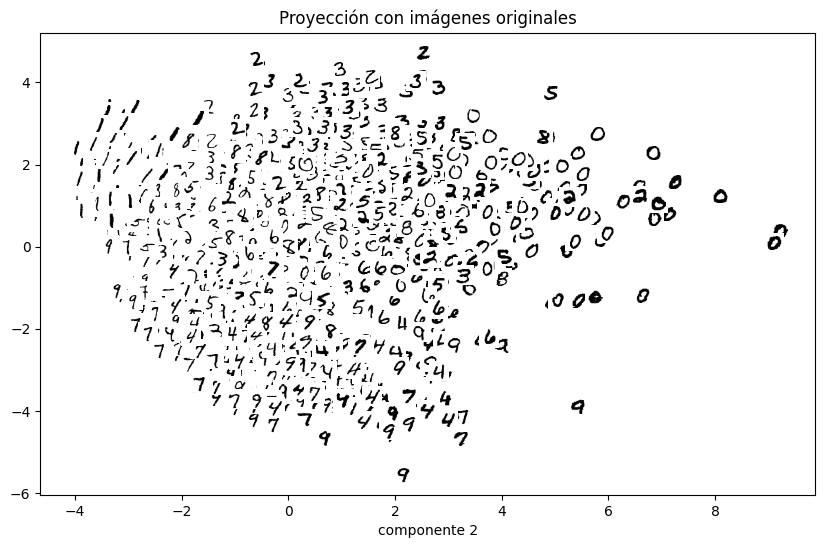

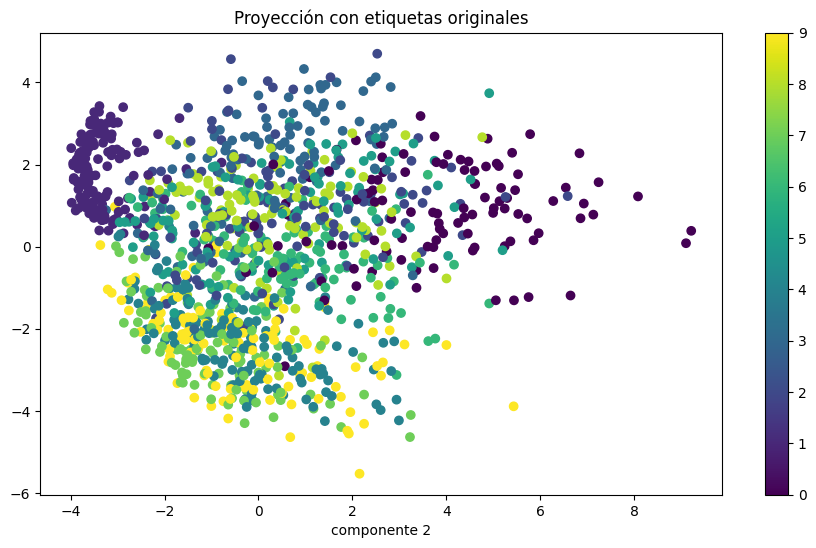

In [ ]:
plot_mnist_2d(Z,X_train,img_w=28,img_h=28,zoom=0.5,cmap='binary')
plt.xlabel('componente 1')
plt.xlabel('componente 2')
plt.title('Proyección con imágenes originales')
plt.show()

plt.figure(figsize=(11,6))
plt.scatter(Z[:,0],Z[:,1],c=y_train)
plt.xlabel('componente 1')
plt.xlabel('componente 2')
plt.title('Proyección con etiquetas originales')
plt.colorbar()
plt.show()

#**graficar componentes como "eigenfaces"**

In [ ]:
#graficar componentes como "eigenfaces"
print(red.components_.shape)

(80, 784)


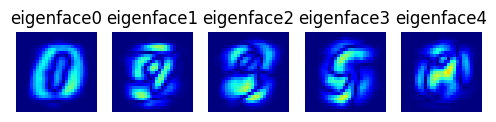

In [ ]:
n_rows = 1
n_cols = 5
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
#resolución imagenes
img_w = 28
img_h = 28

for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(abs(red.components_[index].reshape(img_w,img_h)),
                    vmin=abs(red.components_).min(), vmax=abs(red.components_).max(),cmap="jet", interpolation="nearest")
        plt.axis('off')
        plt.title("eigenface" + str(index), fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
#save_fig('fashion_mnist_plot', tight_layout=False)
plt.show()

##**Parte 2**

Utilizando la base de datos muestreada Mnist en `X_train` y `y_train`, realice una análisis comparativo en términos del coeficiente de silueta del agrupamiento de los datos a 2 dimensiones utilizando kmeans. Considere los métodos: PCA, kernel PCA rbf, t-SNE y UMAP. Utilice la librería [RAPIDS](https://rapids.ai/) a la hora de implementar los algoritmos, en caso de estar disponibles.

#**Instalación de la libreria umap**

In [ ]:
!pip install umap-learn #librería umap
!pip install datashader bokeh holoviews #gráficos umap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 87.4 MB/s eta 0:00:00


##  **Comparación de PCA, KernelPCA, t-SNE y UMAP en MNIST con KMeans**

Submuestreo: (1200, 784)


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:405: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return init_func(self, *args, **filtered_kwargs)


[2025-06-11 14:08:55.251] [CUML] [info] build_algo set to brute_force_knn because random_state is given


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:195: FutureWarning: The default value of `n_init` will change from 1 to 'auto' in 25.04. Set the value of `n_init` explicitly to suppress this warning.
  return func(*args, **kwargs)


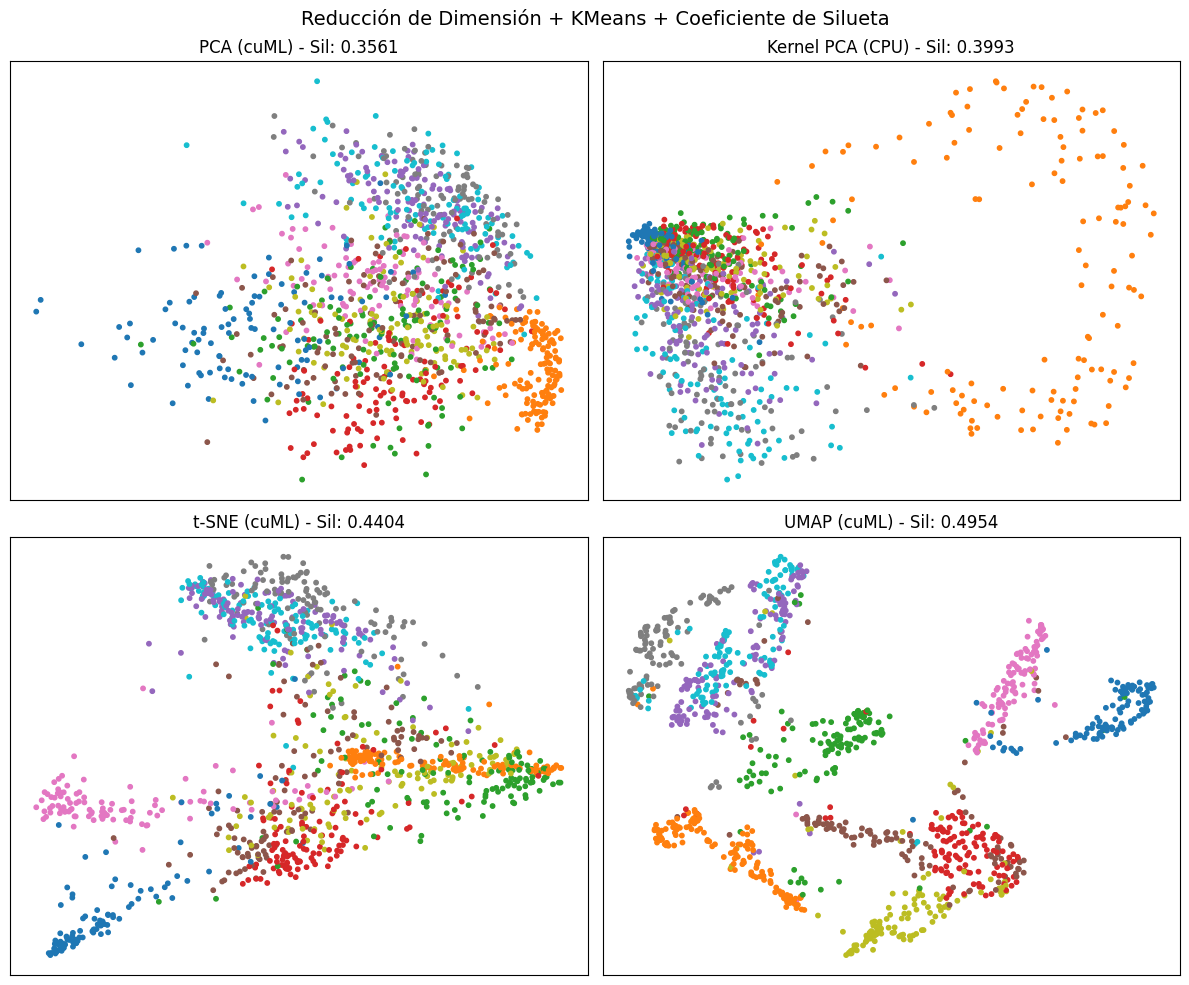

In [ ]:
import cupy as cp
import cudf
import numpy as np
import matplotlib.pyplot as plt
from cuml.decomposition import PCA as cuPCA
from cuml.manifold import TSNE as cuTSNE, UMAP as cuUMAP
from cuml.cluster import KMeans as cuKMeans
from sklearn.decomposition import KernelPCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# === 1. Cargar y preparar datos ===
(X_full, y_full), (_, _) = keras.datasets.mnist.load_data()
X = X_full.reshape(X_full.shape[0], -1) / 255.0
y = y_full

# === 2. Submuestreo para aceleración (puedes ajustar tamaño) ===
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.98, random_state=123)
print("Submuestreo:", X_train.shape)

# Convertir a estructuras RAPIDS
X_gpu = cudf.DataFrame(X_train)
X_cpu = X_train  # para KernelPCA y silhouette

# === 3. Reducción de dimensión ===
X_pca   = cuPCA(n_components=2).fit_transform(X_gpu).to_pandas().values
X_kpca  = KernelPCA(n_components=2, kernel='rbf', gamma=0.03).fit_transform(X_cpu)
X_tsne  = cuTSNE(n_components=2, perplexity=10, learning_rate=200, n_iter=1000, random_state=42).fit_transform(X_gpu).to_pandas().values
X_umap  = cuUMAP(n_components=2, random_state=42).fit_transform(X_gpu).to_pandas().values

# === 4. KMeans clustering ===
kmeans = cuKMeans(n_clusters=10, random_state=42)
clusters_pca   = kmeans.fit_predict(X_pca)
clusters_kpca  = kmeans.fit_predict(X_kpca)
clusters_tsne  = kmeans.fit_predict(X_tsne)
clusters_umap  = kmeans.fit_predict(X_umap)

# === 5. Evaluación con coeficiente de silueta ===
sil_pca   = silhouette_score(X_pca, clusters_pca)
sil_kpca  = silhouette_score(X_kpca, clusters_kpca)
sil_tsne  = silhouette_score(X_tsne, clusters_tsne)
sil_umap  = silhouette_score(X_umap, clusters_umap)

# === 6. Visualización con coeficientes en el título ===
titles = [
    f'PCA (cuML) - Sil: {sil_pca:.4f}',
    f'Kernel PCA (CPU) - Sil: {sil_kpca:.4f}',
    f't-SNE (cuML) - Sil: {sil_tsne:.4f}',
    f'UMAP (cuML) - Sil: {sil_umap:.4f}'
]
datasets = [X_pca, X_kpca, X_tsne, X_umap]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, title, data in zip(axes.ravel(), titles, datasets):
    ax.scatter(data[:, 0], data[:, 1], c=y_train, cmap='tab10', s=10)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Reducción de Dimensión + KMeans + Coeficiente de Silueta', fontsize=14)
plt.tight_layout()
plt.show()


## **Interpretación**

El **coeficiente de silueta** mide qué tan bien separados están los grupos formados por KMeans después de proyectar los datos a 2D. Se interpreta así:

- **Cerca de 1.0**: excelente separación entre grupos.
- **Cerca de 0.0**: los grupos se superponen.
- **Menor a 0**: los datos están mal agrupados.

---

### **¿Qué indican tus resultados?**

- **UMAP** fue la mejor técnica de reducción (0.4954), lo que sugiere que conservó mejor la estructura de agrupamiento de los datos.
- **t-SNE** también lo hizo muy bien (0.4404), como se esperaba (es excelente para visualización).
- **Kernel PCA** (0.3993) superó a **PCA lineal**, lo que indica que la estructura no lineal es relevante en MNIST.
- **PCA** es el más simple y más rápido, pero agrupó peor (0.3561), lo cual también es esperable.